**Ridge Regression**

Ridge Regression (also known as L2 Regularization) is a technique used when the data suffers from multicollinearity (independent variables are highly correlated) or when you have too many features.

In standard OLS, if features are correlated, the coefficients ($w$) can become extremely large and unstable. Ridge Regression forces the coefficients to stay small by adding a penalty proportional to the square of the magnitude of the coefficients.

The Modified Cost Function:
Instead of just minimizing MSE, we minimize:

$$J(w) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{m} w_j^2$$

$\alpha$ (Alpha): The parameter.
* If $\alpha = 0$, it is the same as Ordinary Least Squares.
* If $\alpha \to \infty$, all coefficients shrink toward zero (but never exactly zero).

We can solve Ridge Regression using the Closed-Form (Normal Equation) or Gradient Descent. Here is the modified Normal Equation:

$$\hat{w} = (X^T X + \alpha I)^{-1} X^T y$$

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

diabetes = datasets.load_diabetes()
X, y = diabetes.data, diabetes.target.reshape(-1, 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def manual_ridge_fit(X, y, alpha):
    n_samples, n_features = X.shape
    
    X_bias = np.c_[np.ones((n_samples, 1)), X]
    
    I = np.eye(n_features + 1)
    I[0, 0] = 0 
    
    weights = np.linalg.inv(X_bias.T @ X_bias + alpha * I) @ X_bias.T @ y
    return weights[0][0], weights[1:].flatten()

alpha_val = 1.0
m_intercept, m_coeffs = manual_ridge_fit(X_scaled, y, alpha=alpha_val)

sk_ridge = Ridge(alpha=alpha_val)
sk_ridge.fit(X_scaled, y)

print(f"Manual Intercept: {m_intercept:.4f} | Sklearn: {sk_ridge.intercept_[0]:.4f}")
print(f"Coefficients match? {np.allclose(m_coeffs, sk_ridge.coef_.flatten())}")

Manual Intercept: 152.1335 | Sklearn: 152.1335
Coefficients match? True


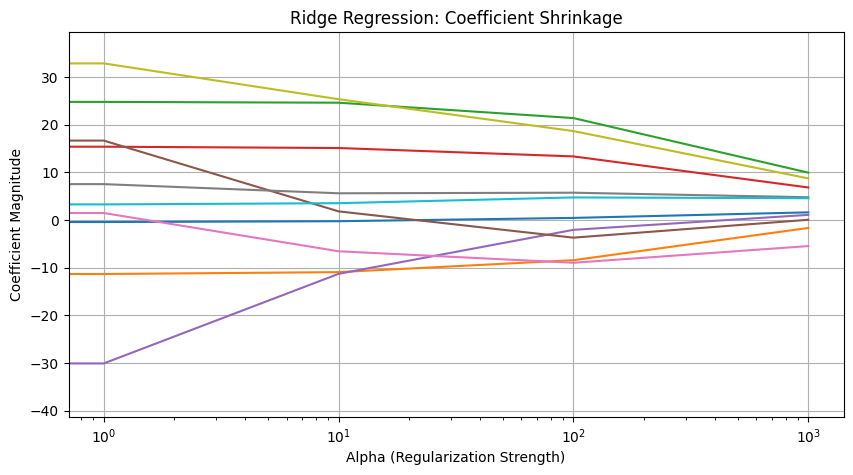

In [3]:
import matplotlib.pyplot as plt

alphas = [0, 1, 10, 100, 1000]
coef_history = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_scaled, y)
    coef_history.append(model.coef_.flatten())

plt.figure(figsize=(10, 5))
plt.plot(alphas, coef_history)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Magnitude')
plt.title('Ridge Regression: Coefficient Shrinkage')
plt.grid(True)
plt.show()